# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

### Area Plot vs. Two Line Graphs

I think an area plot works well if the goal is to show the overall nutrient level in the water over time. It makes it easy to see the combined contribution of nitrate and phosphate and how that total changes.

The downside is that it can be harder to compare the two chemicals individually. Since one area is stacked on top of the other, it's not always easy to tell the exact phosphate level because the top line represents the total of both chemicals.

If the goal is to compare nitrate and phosphate directly, I would choose two line graphs instead. They make it much easier to see how each chemical changes over time and whether one increases or decreases faster than the other.

To improve either graph, I would add a clear title, label both axes with the appropriate units, and use direct labels instead of relying only on a legend. I would also remove unnecessary chart elements so the focus stays on the data, following the principles from Storytelling with Data.

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

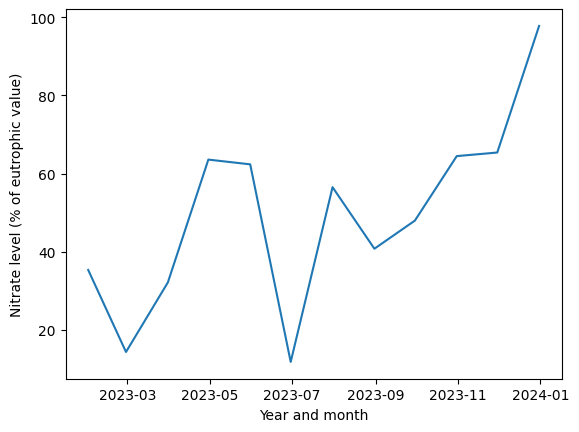

In [3]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

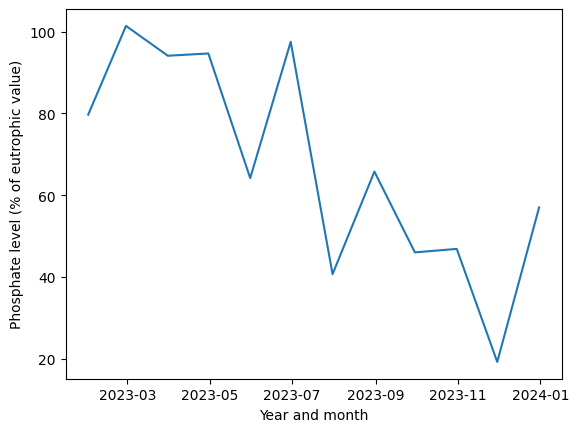

In [5]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

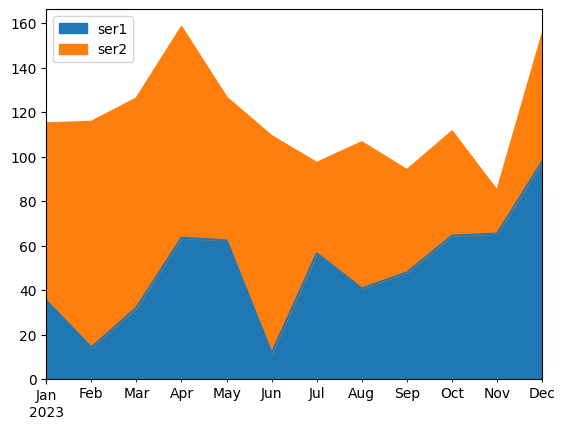

In [6]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=["number"])

corr = numeric_df.corr()

corr

,ser1,ser2
ser1,1.000000,-0.615478
ser2,-0.615478,1.000000


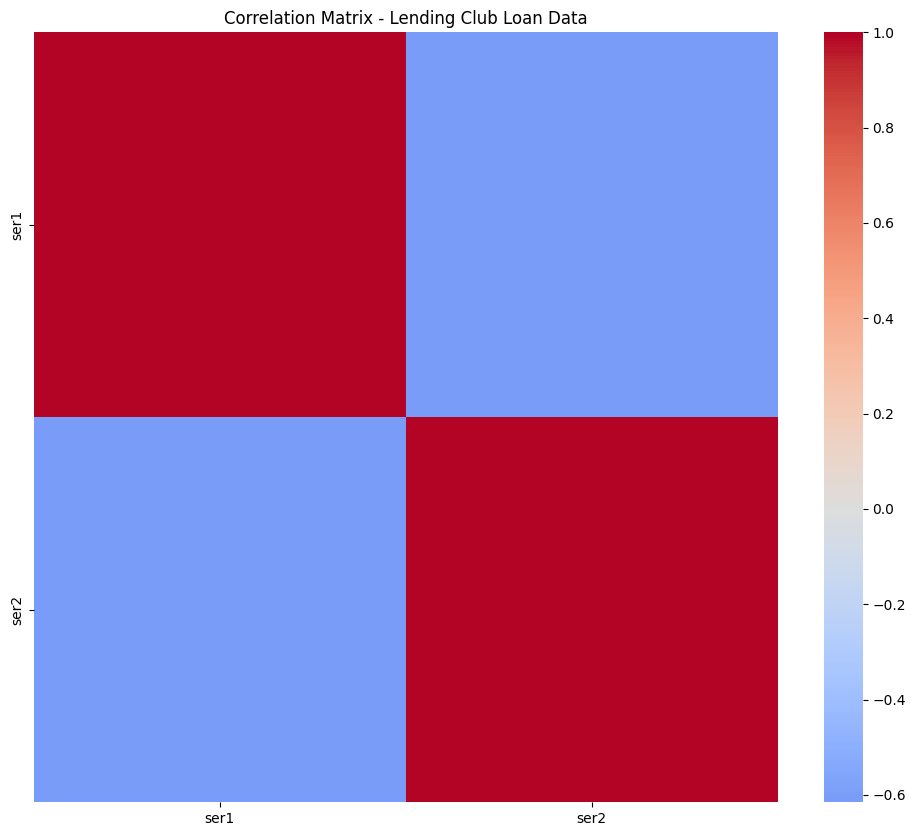

In [9]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix - Lending Club Loan Data")
plt.show()

In [12]:
%whos

Variable        Type             Data/Info
------------------------------------------
ax              Axes             Axes(0.125,0.11;0.775x0.77)
corr            DataFrame        Shape: (2, 2)
datearray       DatetimeIndex    DatetimeIndex(['2023-01-3<...>tetime64[us]', freq='ME')
df              DataFrame        Shape: (12, 2)
np              module           <module 'numpy' from '/us<...>kages/numpy/__init__.py'>
numdates        int              12
numeric_df      DataFrame        Shape: (12, 2)
pd              module           <module 'pandas' from '/u<...>ages/pandas/__init__.py'>
plt             module           <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
sns             module           <module 'seaborn' from '/<...>ges/seaborn/__init__.py'>
time_series     ndarray          12: 12 elems, type `float64`, 96 bytes
time_series_2   ndarray          12: 12 elems, type `float64`, 96 bytes


In [13]:
import kagglehub

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
path = kagglehub.dataset_download("wordsforthewise/lending-club")

In [15]:
import os
import pandas as pd

folder_path = os.path.join(path, "accepted_2007_to_2018q4.csv")

files_inside = os.listdir(folder_path)

true_csv_path = os.path.join(folder_path, files_inside[0])

df_accepted = pd.read_csv(true_csv_path, nrows=5000)

/tmp/ipykernel_115071/1487585801.py:10: DtypeWarning: Columns (0: desc) have mixed types. Specify dtype option on import or set low_memory=False.
  df_accepted = pd.read_csv(true_csv_path, nrows=5000)


In [16]:
df = df_accepted.copy()

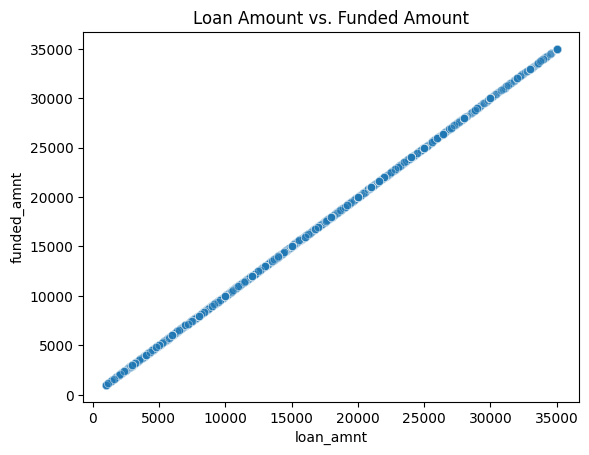

In [17]:
sns.scatterplot(
    data=df_accepted,
    x="loan_amnt",
    y="funded_amnt",
    alpha=0.4
)

plt.title("Loan Amount vs. Funded Amount")
plt.show()

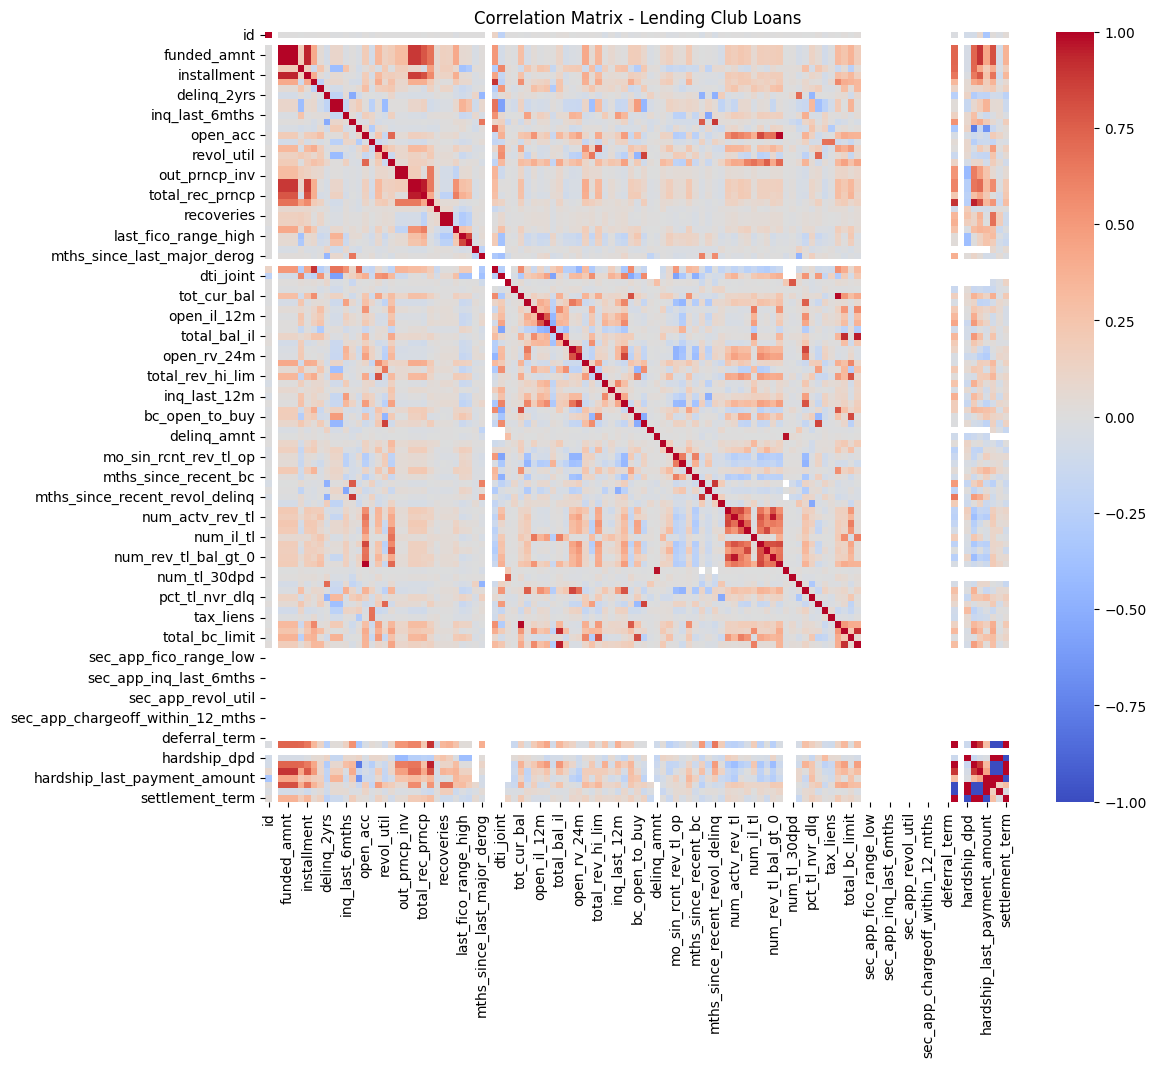

In [18]:
numeric_df = df_accepted.select_dtypes(include="number")

corr = numeric_df.corr()

plt.figure(figsize=(12,10))

sns.heatmap(corr, cmap="coolwarm", center=0)

plt.title("Correlation Matrix - Lending Club Loans")

plt.show()

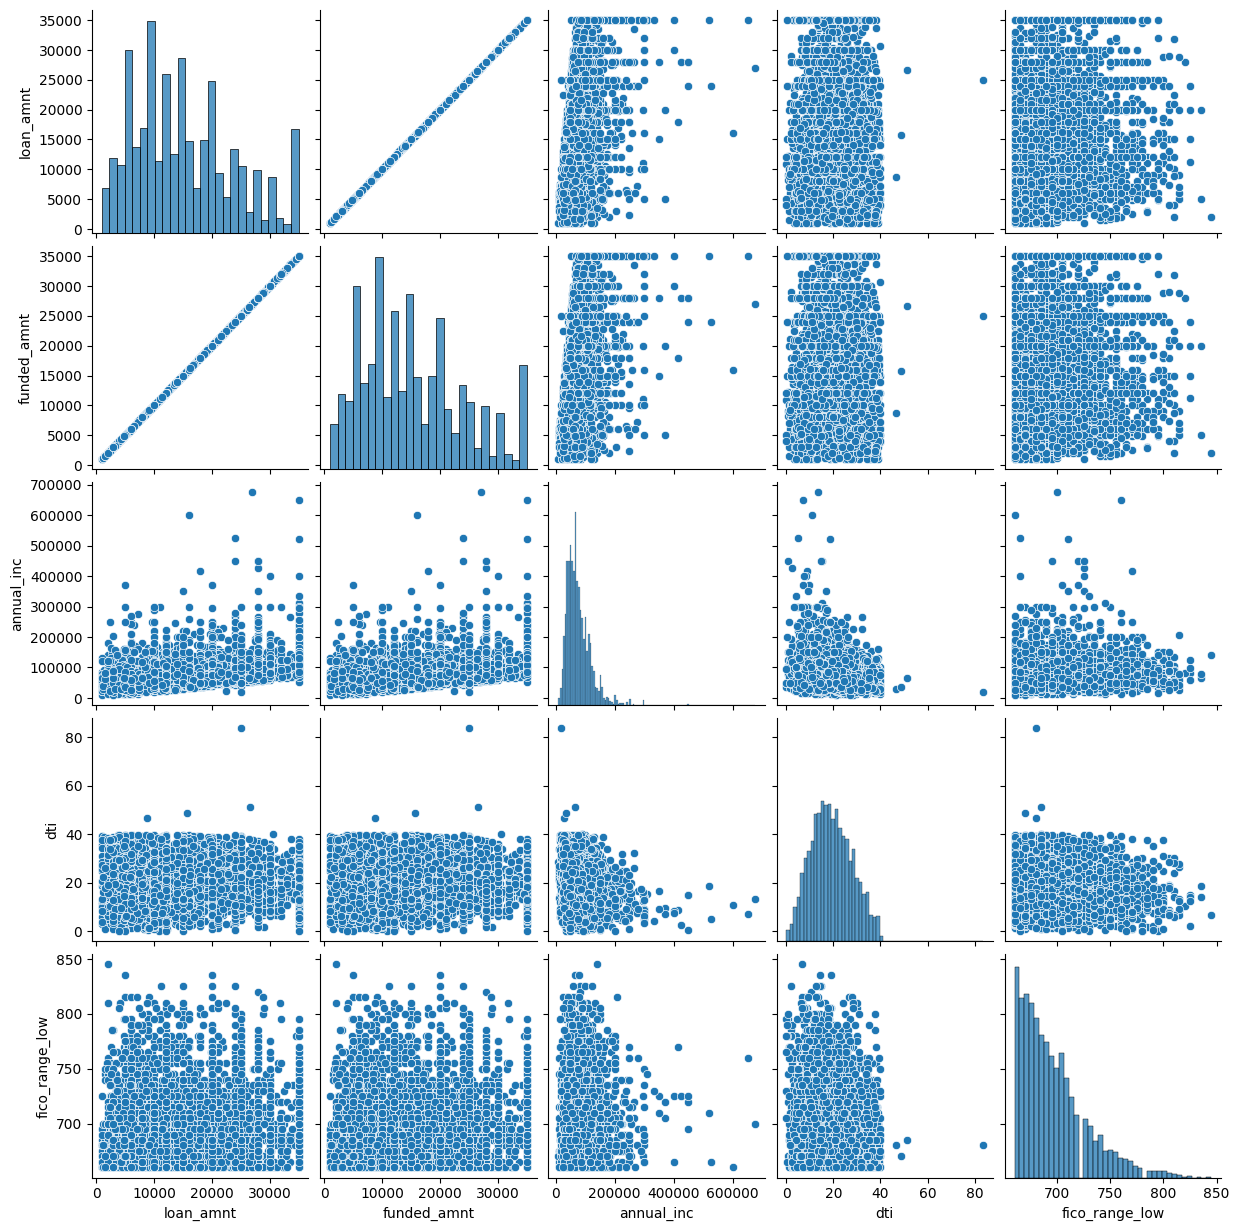

In [19]:
pair_df = df_accepted[
    [
        "loan_amnt",
        "funded_amnt",
        "annual_inc",
        "dti",
        "fico_range_low"
    ]
]

sns.pairplot(pair_df)

issue_d
2015-12    5000
Freq: M, dtype: int64


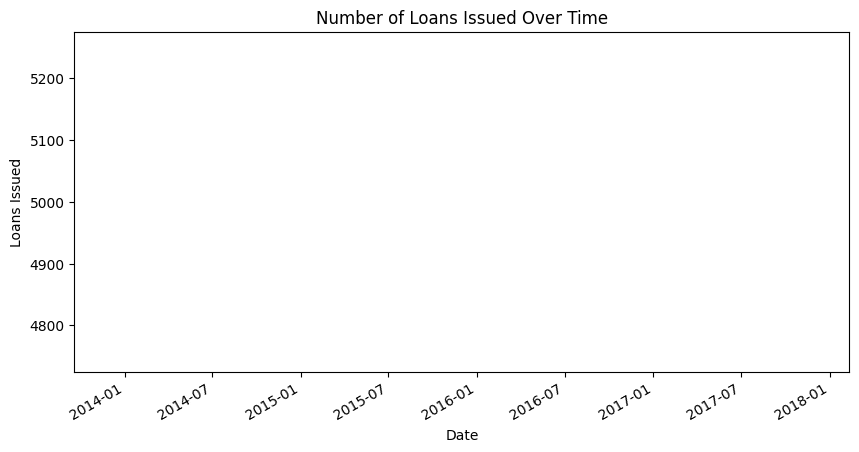

In [22]:
import matplotlib.pyplot as plt

monthly_loans = (
    df_accepted
    .dropna(subset=["issue_d"])
    .groupby(df_accepted["issue_d"].dt.to_period("M"))
    .size()
)

print(monthly_loans)

monthly_loans.index = monthly_loans.index.to_timestamp()

monthly_loans.plot(figsize=(10,5))

plt.title("Number of Loans Issued Over Time")
plt.xlabel("Date")
plt.ylabel("Loans Issued")
plt.show()

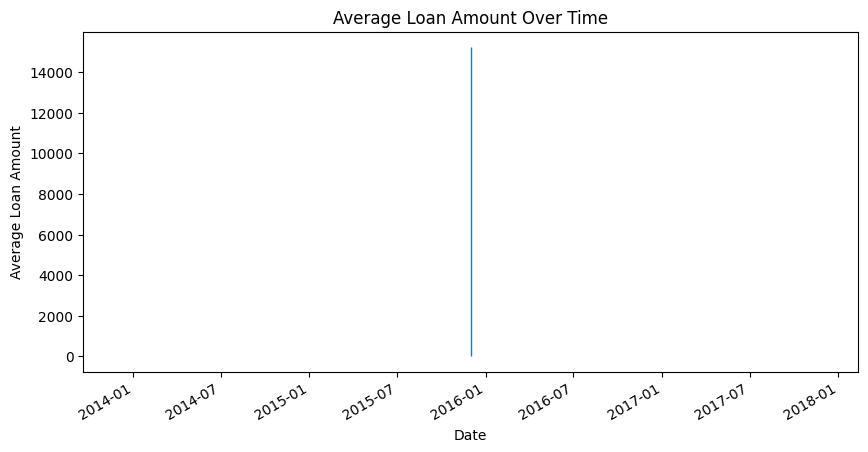

In [21]:
monthly_avg = (
    df_accepted
    .groupby(df_accepted["issue_d"].dt.to_period("M"))["loan_amnt"]
    .mean()
)

monthly_avg.index = monthly_avg.index.to_timestamp()

monthly_avg.plot.area(figsize=(10,5))

plt.title("Average Loan Amount Over Time")
plt.xlabel("Date")
plt.ylabel("Average Loan Amount")

plt.show()

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

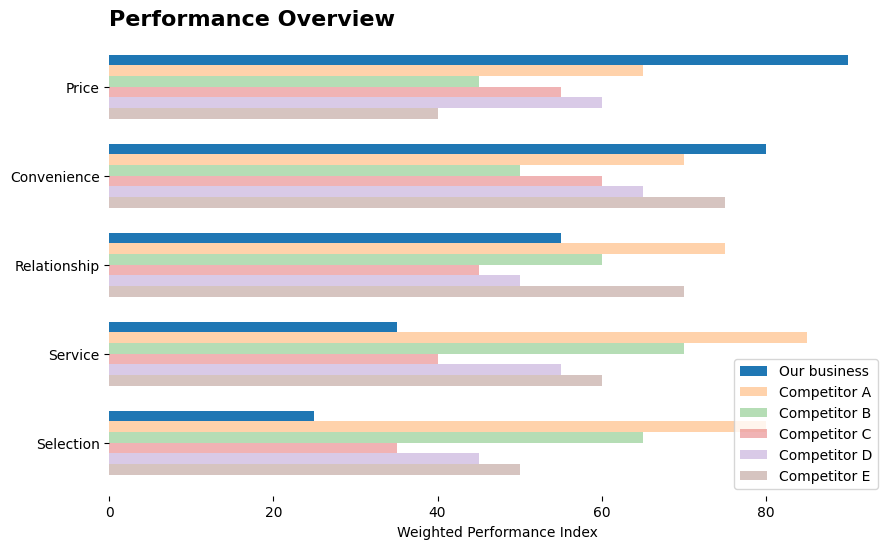

In [24]:
categories = ["Price", "Convenience", "Relationship", "Service", "Selection"]

our_business = [90, 80, 55, 35, 25]
competitor_a = [65, 70, 75, 85, 80]
competitor_b = [45, 50, 60, 70, 65]
competitor_c = [55, 60, 45, 40, 35]
competitor_d = [60, 65, 50, 55, 45]
competitor_e = [40, 75, 70, 60, 50]

data = [
    our_business,
    competitor_a,
    competitor_b,
    competitor_c,
    competitor_d,
    competitor_e
]

labels = [
    "Our business",
    "Competitor A",
    "Competitor B",
    "Competitor C",
    "Competitor D",
    "Competitor E"
]

y = np.arange(len(categories))
bar_height = 0.12

plt.figure(figsize=(10, 6))

for i, values in enumerate(data):
    offset = (i - 2.5) * bar_height
    
    if i == 0:
        plt.barh(y + offset, values, height=bar_height, label=labels[i])
    else:
        plt.barh(y + offset, values, height=bar_height, label=labels[i], alpha=0.35)

plt.yticks(y, categories)
plt.gca().invert_yaxis()

plt.title("Performance Overview", loc="left", fontsize=16, fontweight="bold")
plt.xlabel("Weighted Performance Index")
plt.ylabel("")

plt.legend(loc="lower right")
plt.grid(False)

plt.box(False)

plt.show()